## Importing Libraries

In [16]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow.keras.utils import image_dataset_from_directory 

# Data Preparation

In [17]:
training_set = image_dataset_from_directory(
     "../ZhangLabData/CellData/OCT/train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,  
)


Found 108309 files belonging to 4 classes.


In [19]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

## Dataset Overview (Basic EDA)
### We are Checking
1.Number of classes
2.Total images per class
3.Image shape & datatype

In [21]:
import os
import pandas as pd
data_dir = "../ZhangLabData/CellData/OCT/train"
classes = os.listdir(data_dir)

data =[]
for cls in classes:
    path= os.path.join(data_dir,cls)
    count = len(os.listdir(path))
    data.append([cls,count])

df = pd.DataFrame(data, columns=["Class","No_of_Images"])
print(df)

    Class  No_of_Images
0     CNV         37205
1     DME         11348
2  DRUSEN          8616
3  NORMAL         51140


## Class Distribution Visualization

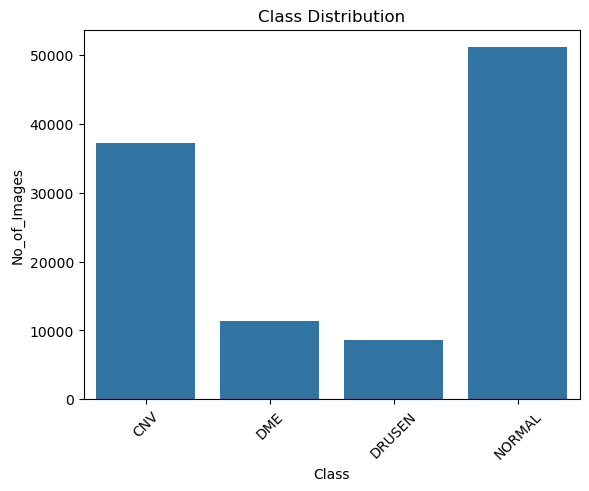

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=df["Class"],y= df["No_of_Images"])
plt.title("Class Distribution")
plt.xticks(rotation= 45)
plt.show()

#### Dataset shows class imbalance, therefore data augmentation was applied to minority classes to improve model generalization and reduce bias.

In [27]:
class_names = training_set.class_names
print(class_names)


['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [28]:
minority_classes = [1, 2]   # DME, DRUSEN


In [34]:
# Example minority class indices
minority_classes = tf.constant([0, 2], dtype=tf.int32)

def augment_if_minority(images, labels):

    # Convert one-hot labels → class index
    class_indices = tf.argmax(labels, axis=1, output_type=tf.int32)

    def augment_image(img, cls):
        return tf.cond(
            tf.reduce_any(tf.equal(cls, minority_classes)),
            lambda: data_augmentation(img, training=True),
            lambda: img
        )

    images = tf.map_fn(
        lambda x: augment_image(x[0], x[1]),
        (images, class_indices),
        fn_output_signature=tf.float32  # replaces deprecated dtype
    )

    return images, labels

training_set_aug = training_set.map(
    augment_if_minority,
    num_parallel_calls=tf.data.AUTOTUNE
)


In [35]:
for images, labels in training_set_aug.take(1):
    print(images.shape, labels.shape)


(32, 224, 224, 3) (32, 4)


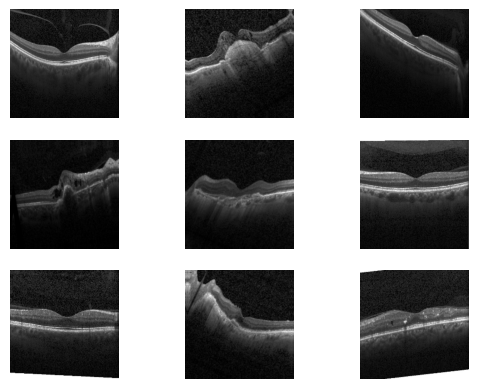

In [40]:
# Checking Augmented images

for images, labels in training_set_aug.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy()/255.0)  # Important
        plt.axis("off")
plt.show()


## 3. Visual Inspection of Images
Helps detect:
Blur images, 
Wrong labels, 
Noise/artifacts

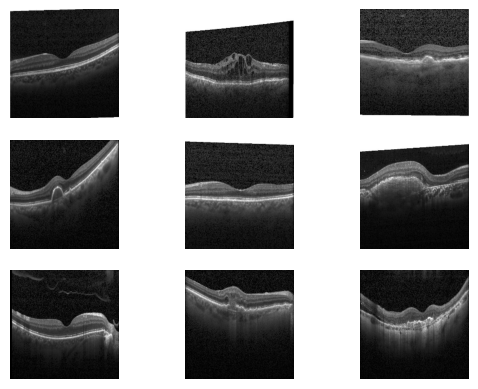

In [42]:
import matplotlib.pyplot as plt

for images, labels in training_set.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")
plt.show()


## Image Normalization

In [45]:
# Normalize pixel values: 
normalization_layer = tf.keras.layers.Rescaling(1./255)

training_set = training_set.map(lambda x, y: (normalization_layer(x), y))


## Data Augmentation

In [46]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

training_set = training_set.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)


## Train Validation Split

In [47]:
train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32
)
val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)


Found 108309 files belonging to 4 classes.
Using 86648 files for training.
Found 108309 files belonging to 4 classes.
Using 21661 files for validation.


## Performance Optimization

In [50]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)